In [2]:
pip install yfinance pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ═══════════════════════════════════════════════
# PROJECT 3 — Fixed Data Fetch
# ═══════════════════════════════════════════════

import yfinance as yf
import pandas as pd
import numpy as np

# ── Use individual NSE stocks per sector ───────
# These tickers are confirmed working on yfinance

sectors = {
    'Banking'  : ['HDFCBANK.NS', 'ICICIBANK.NS', 'KOTAKBANK.NS', 'SBIN.NS', 'AXISBANK.NS'],
    'IT'       : ['TCS.NS', 'INFY.NS', 'WIPRO.NS', 'HCLTECH.NS', 'TECHM.NS'],
    'Pharma'   : ['SUNPHARMA.NS', 'DRREDDY.NS', 'CIPLA.NS', 'DIVISLAB.NS', 'APOLLOHOSP.NS'],
    'Auto'     : ['MARUTI.NS', 'TATAMOTORS.NS', 'BAJAJ-AUTO.NS', 'HEROMOTOCO.NS', 'EICHERMOT.NS'],
    'FMCG'     : ['HINDUNILVR.NS', 'ITC.NS', 'NESTLEIND.NS', 'BRITANNIA.NS', 'DABUR.NS'],
    'Energy'   : ['RELIANCE.NS', 'ONGC.NS', 'NTPC.NS', 'POWERGRID.NS', 'BPCL.NS'],
    'Metal'    : ['TATASTEEL.NS', 'JSWSTEEL.NS', 'HINDALCO.NS', 'VEDL.NS', 'COALINDIA.NS'],
    'Realty'   : ['DLF.NS', 'GODREJPROP.NS', 'OBEROIRLTY.NS', 'PRESTIGE.NS', 'BRIGADE.NS'],
    'Infra'    : ['LT.NS', 'ADANIPORTS.NS', 'ADANIENT.NS', 'SIEMENS.NS', 'ABB.NS'],
    'Media'    : ['ZEEL.NS', 'SUNTV.NS', 'PVRINOX.NS', 'DISHTV.NS', 'TIPS.NS']
}

print("Fetching data... please wait")
all_data = []

for sector, tickers in sectors.items():
    for ticker in tickers:
        try:
            stock = yf.Ticker(ticker)
            hist = stock.history(start='2023-01-01', end='2024-12-31')
            if len(hist) > 0:
                hist = hist.reset_index()
                hist['Sector'] = sector
                hist['Ticker'] = ticker
                hist['Company'] = ticker.replace('.NS', '')
                all_data.append(hist)
                print(f"✓ {ticker}")
            else:
                print(f"✗ {ticker} — no data")
        except Exception as e:
            print(f"✗ {ticker} — {e}")

# ── Combine ────────────────────────────────────
df = pd.concat(all_data, ignore_index=True)

# ── Clean ──────────────────────────────────────
df = df[['Date', 'Open', 'High', 'Low', 'Close', 
         'Volume', 'Sector', 'Ticker', 'Company']]
df['Date'] = pd.to_datetime(df['Date']).dt.date
df['Return'] = df.groupby('Ticker')['Close'].pct_change() * 100
df['Return'] = df['Return'].round(4)

print(f"\n✓ Total rows: {len(df)}")
print(f"✓ Sectors: {df['Sector'].nunique()}")
print(f"✓ Companies: {df['Ticker'].nunique()}")
print(f"✓ Date range: {df['Date'].min()} to {df['Date'].max()}")
print("\nSample data:")
print(df.head())

# ── Save ───────────────────────────────────────
df.to_csv('nse_sector_data.csv', index=False)
print("\n✓ Saved as nse_sector_data.csv")

Fetching data... please wait
✓ HDFCBANK.NS
✓ ICICIBANK.NS
✓ KOTAKBANK.NS
✓ SBIN.NS
✓ AXISBANK.NS
✓ TCS.NS
✓ INFY.NS
✓ WIPRO.NS
✓ HCLTECH.NS
✓ TECHM.NS
✓ SUNPHARMA.NS
✓ DRREDDY.NS
✓ CIPLA.NS
✓ DIVISLAB.NS
✓ APOLLOHOSP.NS
✓ MARUTI.NS


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found


✗ TATAMOTORS.NS — no data
✓ BAJAJ-AUTO.NS
✓ HEROMOTOCO.NS
✓ EICHERMOT.NS
✓ HINDUNILVR.NS
✓ ITC.NS
✓ NESTLEIND.NS
✓ BRITANNIA.NS
✓ DABUR.NS
✓ RELIANCE.NS
✓ ONGC.NS
✓ NTPC.NS
✓ POWERGRID.NS
✓ BPCL.NS
✓ TATASTEEL.NS
✓ JSWSTEEL.NS
✓ HINDALCO.NS
✓ VEDL.NS
✓ COALINDIA.NS
✓ DLF.NS
✓ GODREJPROP.NS
✓ OBEROIRLTY.NS
✓ PRESTIGE.NS
✓ BRIGADE.NS
✓ LT.NS
✓ ADANIPORTS.NS
✓ ADANIENT.NS
✓ SIEMENS.NS
✓ ABB.NS
✓ ZEEL.NS
✓ SUNTV.NS
✓ PVRINOX.NS


$TIPS.NS: possibly delisted; no price data found  (1d 2023-01-01 -> 2024-12-31)


✓ DISHTV.NS
✗ TIPS.NS — no data

✓ Total rows: 23501
✓ Sectors: 10
✓ Companies: 48
✓ Date range: 2023-01-02 to 2024-12-30

Sample data:
         Date        Open        High         Low       Close    Volume  \
0  2023-01-02  782.859895  788.994783  778.794051  783.677856   4381378   
1  2023-01-03  780.550329  790.558642  780.550329  788.802368   8378030   
2  2023-01-04  786.709336  791.881890  773.236638  774.704224  10351600   
3  2023-01-05  777.086012  778.553597  764.768128  769.724121  10941436   
4  2023-01-06  770.830752  774.247032  759.378936  767.173889   9092462   

    Sector       Ticker   Company  Return  
0  Banking  HDFCBANK.NS  HDFCBANK     NaN  
1  Banking  HDFCBANK.NS  HDFCBANK  0.6539  
2  Banking  HDFCBANK.NS  HDFCBANK -1.7873  
3  Banking  HDFCBANK.NS  HDFCBANK -0.6428  
4  Banking  HDFCBANK.NS  HDFCBANK -0.3313  

✓ Saved as nse_sector_data.csv


SECTOR PERFORMANCE SUMMARY
         Avg_Daily_Return  Volatility  Avg_Close  Total_Volume
Sector                                                        
Realty              0.223       2.235   1217.814    3517778845
Infra               0.130       2.588   3011.955    6966606066
Energy              0.126       1.707    439.897   35546153855
Auto                0.120       1.476   6199.389    1133851106
Pharma              0.117       1.386   2671.759    3548411348
IT                  0.105       1.434   1542.959   13396785559
Metal               0.093       1.778    416.780   36125332898
Banking             0.044       1.345    776.448   51543414221
FMCG                0.030       1.189   1873.643    9746895140
Media              -0.026       2.614    572.086   22131191718

BEST PERFORMING SECTOR: Realty
WORST PERFORMING SECTOR: Media
MOST VOLATILE SECTOR: Media
LEAST VOLATILE SECTOR: FMCG

ANNUAL RETURN BY SECTOR
     Sector  Year  Annual_Return_%
0      Auto  2023           -50.41
1  

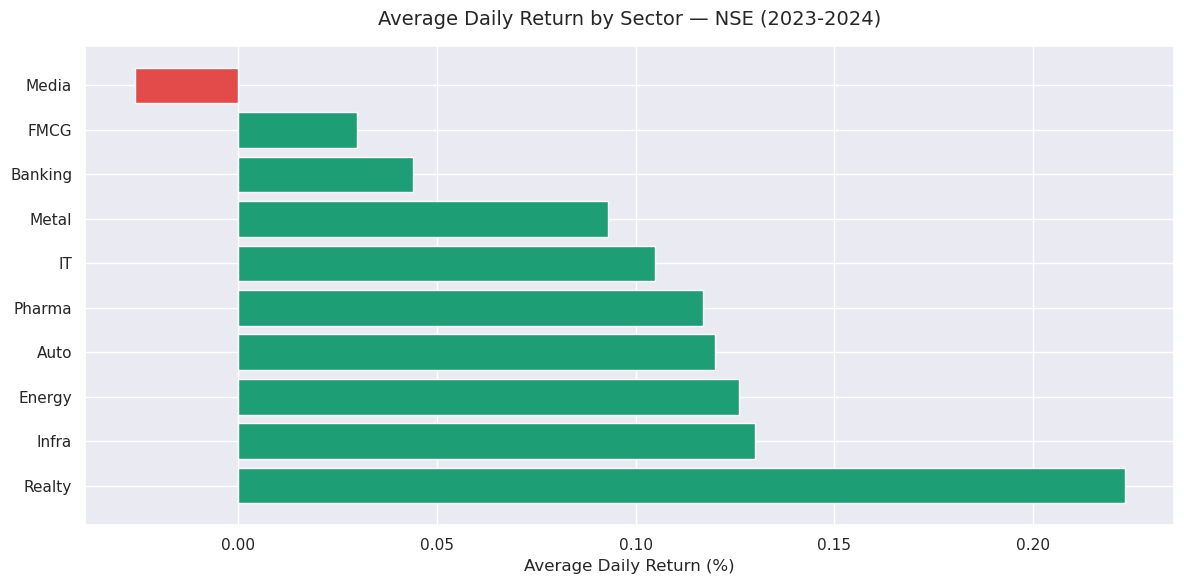

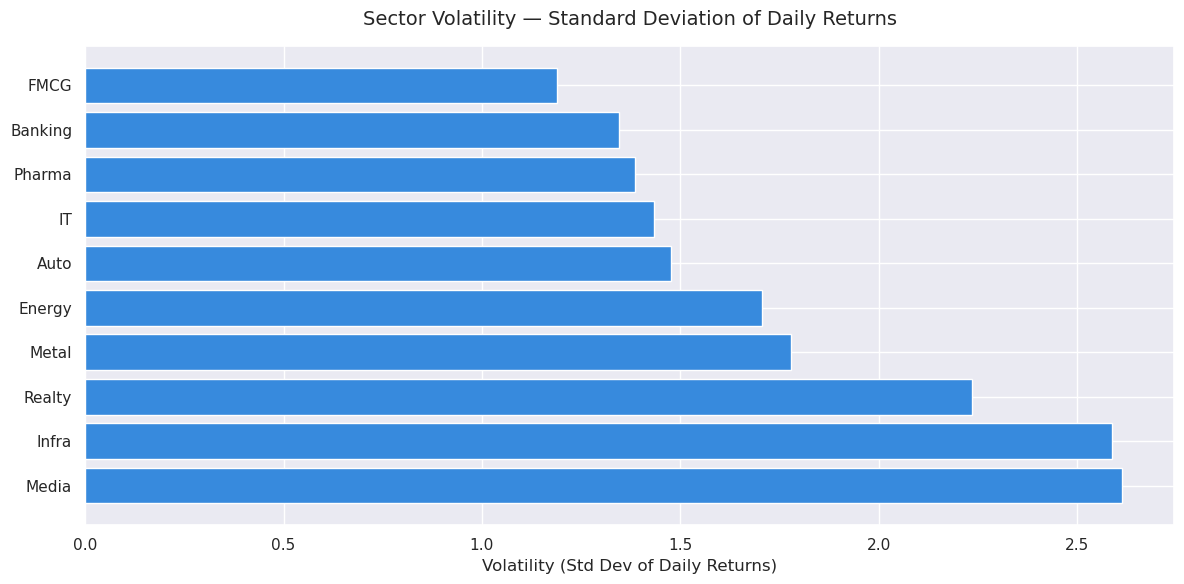

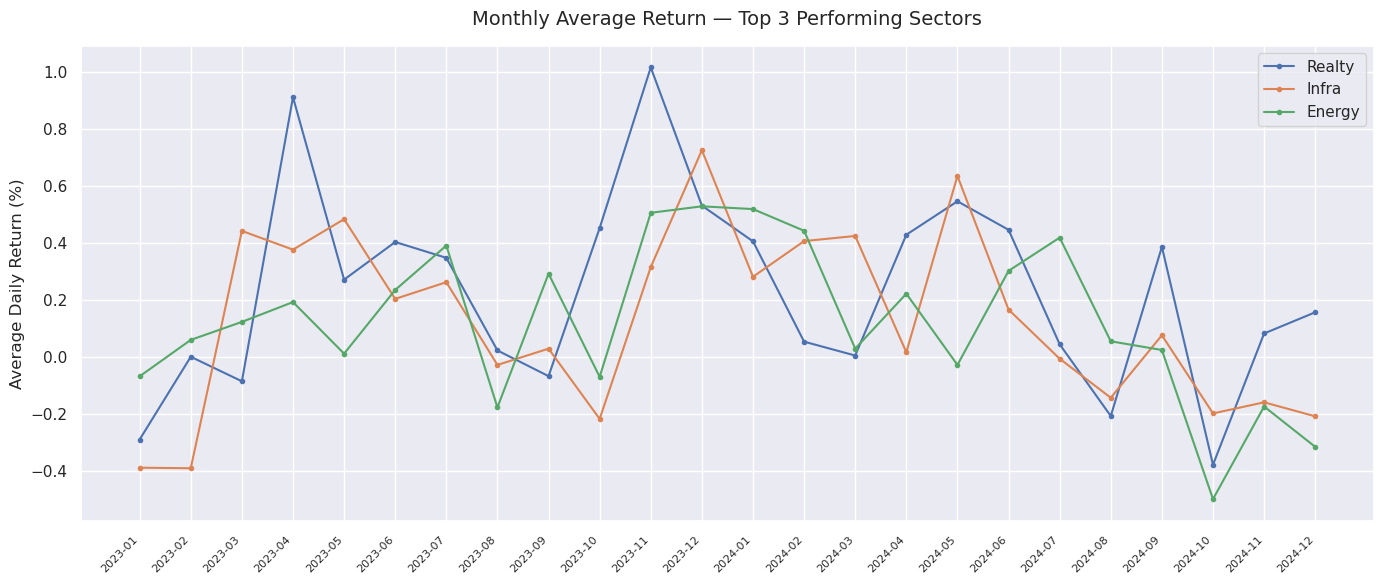

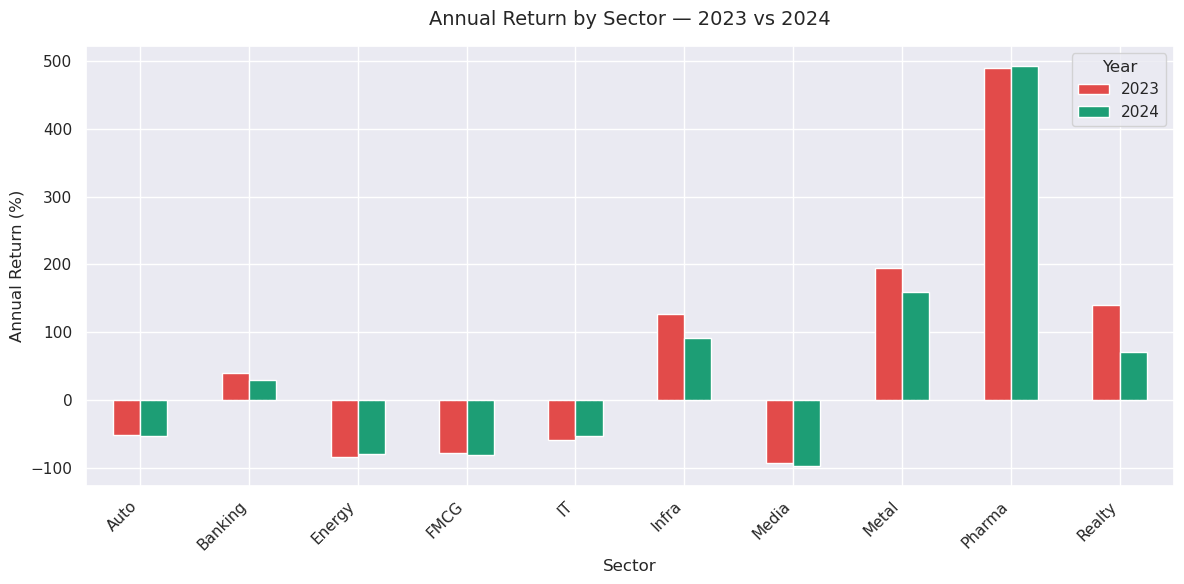


✓ All charts saved!
✓ Files saved for Power BI:
  - nse_powerbi.csv
  - sector_summary.csv
  - annual_returns.csv

KEY FINDINGS:
1. Best sector: Realty (avg return: 0.223%)
2. Worst sector: Media (avg return: -0.026%)
3. Most volatile: Media (std dev: 2.614)
4. Least volatile: FMCG (std dev: 1.189)


In [6]:
# ═══════════════════════════════════════════════
# PROJECT 3 — NSE Sector Analysis
# Complete Analysis Block
# ═══════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = df = pd.read_csv('indian-stock-market-sector-analysis/nse_sector_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ── 1. SECTOR PERFORMANCE SUMMARY ─────────────
print("=" * 55)
print("SECTOR PERFORMANCE SUMMARY")
print("=" * 55)

sector_summary = df.groupby('Sector').agg(
    Avg_Daily_Return  = ('Return', 'mean'),
    Volatility        = ('Return', 'std'),
    Avg_Close         = ('Close', 'mean'),
    Total_Volume      = ('Volume', 'sum')
).round(3).sort_values('Avg_Daily_Return', ascending=False)

print(sector_summary)

# ── 2. BEST AND WORST SECTORS ─────────────────
print("\n" + "=" * 55)
print("BEST PERFORMING SECTOR:", sector_summary.index[0])
print("WORST PERFORMING SECTOR:", sector_summary.index[-1])
print("MOST VOLATILE SECTOR:", sector_summary['Volatility'].idxmax())
print("LEAST VOLATILE SECTOR:", sector_summary['Volatility'].idxmin())

# ── 3. ANNUAL RETURN BY SECTOR ─────────────────
print("\n" + "=" * 55)
print("ANNUAL RETURN BY SECTOR")
print("=" * 55)

# Calculate annual return — first vs last close price
annual = df.groupby(['Sector', 'Year']).agg(
    First_Close = ('Close', 'first'),
    Last_Close  = ('Close', 'last')
).reset_index()
annual['Annual_Return_%'] = ((annual['Last_Close'] - annual['First_Close']) 
                              / annual['First_Close'] * 100).round(2)
print(annual[['Sector', 'Year', 'Annual_Return_%']])

# ── 4. CHARTS ──────────────────────────────────

# Chart 1 — Average Daily Return by Sector
plt.figure(figsize=(12, 6))
colors = ['#1D9E75' if x > 0 else '#E24B4A' 
          for x in sector_summary['Avg_Daily_Return']]
plt.barh(sector_summary.index, 
         sector_summary['Avg_Daily_Return'], 
         color=colors, edgecolor='white')
plt.axvline(x=0, color='white', linestyle='--', linewidth=0.8)
plt.title('Average Daily Return by Sector — NSE (2023-2024)', 
          fontsize=14, pad=15)
plt.xlabel('Average Daily Return (%)')
plt.tight_layout()
plt.savefig('sector_returns.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2 — Volatility by Sector
plt.figure(figsize=(12, 6))
vol_sorted = sector_summary.sort_values('Volatility', ascending=False)
plt.barh(vol_sorted.index, vol_sorted['Volatility'],
         color='#378ADD', edgecolor='white')
plt.title('Sector Volatility — Standard Deviation of Daily Returns', 
          fontsize=14, pad=15)
plt.xlabel('Volatility (Std Dev of Daily Returns)')
plt.tight_layout()
plt.savefig('sector_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3 — Monthly trend for top 3 sectors
top3 = sector_summary.head(3).index.tolist()
monthly = df[df['Sector'].isin(top3)].groupby(
    ['Month', 'Sector'])['Return'].mean().reset_index()

plt.figure(figsize=(14, 6))
for sector in top3:
    data = monthly[monthly['Sector'] == sector]
    plt.plot(data['Month'], data['Return'], 
             marker='o', markersize=3, label=sector, linewidth=1.5)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Monthly Average Return — Top 3 Performing Sectors', 
          fontsize=14, pad=15)
plt.ylabel('Average Daily Return (%)')
plt.legend()
plt.tight_layout()
plt.savefig('top3_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 4 — Annual return comparison 2023 vs 2024
pivot = annual.pivot(index='Sector', 
                     columns='Year', 
                     values='Annual_Return_%')
pivot.plot(kind='bar', figsize=(12, 6),
           color=['#E24B4A', '#1D9E75'], edgecolor='white')
plt.title('Annual Return by Sector — 2023 vs 2024', 
          fontsize=14, pad=15)
plt.ylabel('Annual Return (%)')
plt.xlabel('Sector')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.axhline(y=0, color='white', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('annual_return_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. SAVE FOR POWER BI ───────────────────────
# Save enriched dataset
df.to_csv('nse_powerbi.csv', index=False)
sector_summary.reset_index().to_csv('sector_summary.csv', index=False)
annual.to_csv('annual_returns.csv', index=False)

print("\n✓ All charts saved!")
print("✓ Files saved for Power BI:")
print("  - nse_powerbi.csv")
print("  - sector_summary.csv")
print("  - annual_returns.csv")

print("\nKEY FINDINGS:")
print(f"1. Best sector: {sector_summary.index[0]} "
      f"(avg return: {sector_summary['Avg_Daily_Return'].iloc[0]:.3f}%)")
print(f"2. Worst sector: {sector_summary.index[-1]} "
      f"(avg return: {sector_summary['Avg_Daily_Return'].iloc[-1]:.3f}%)")
print(f"3. Most volatile: {sector_summary['Volatility'].idxmax()} "
      f"(std dev: {sector_summary['Volatility'].max():.3f})")
print(f"4. Least volatile: {sector_summary['Volatility'].idxmin()} "
      f"(std dev: {sector_summary['Volatility'].min():.3f})")